DATA VISUALIZATION


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# ------------------------------------------
# 1. Loading the Taxis Dataset
# ------------------------------------------

df = sns.load_dataset("taxis")

print("First 5 rows:")
print(df.head())


First 5 rows:
               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Si

In [3]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64

In [5]:
# ------------------------------------------
# 2. Handling Missing Values
# ------------------------------------------

print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())


# Convert pickup to datetime
df['pickup'] = pd.to_datetime(df['pickup'])



Missing Values Before Cleaning:
pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [6]:
# Fill numerical missing values with median
numeric_columns = df.select_dtypes(include='number').columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())


In [ ]:
# Fill categorical missing values with mode
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])


In [9]:
# Remove rows with missing critical values
df = df.dropna(subset=['pickup', 'fare'])


print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


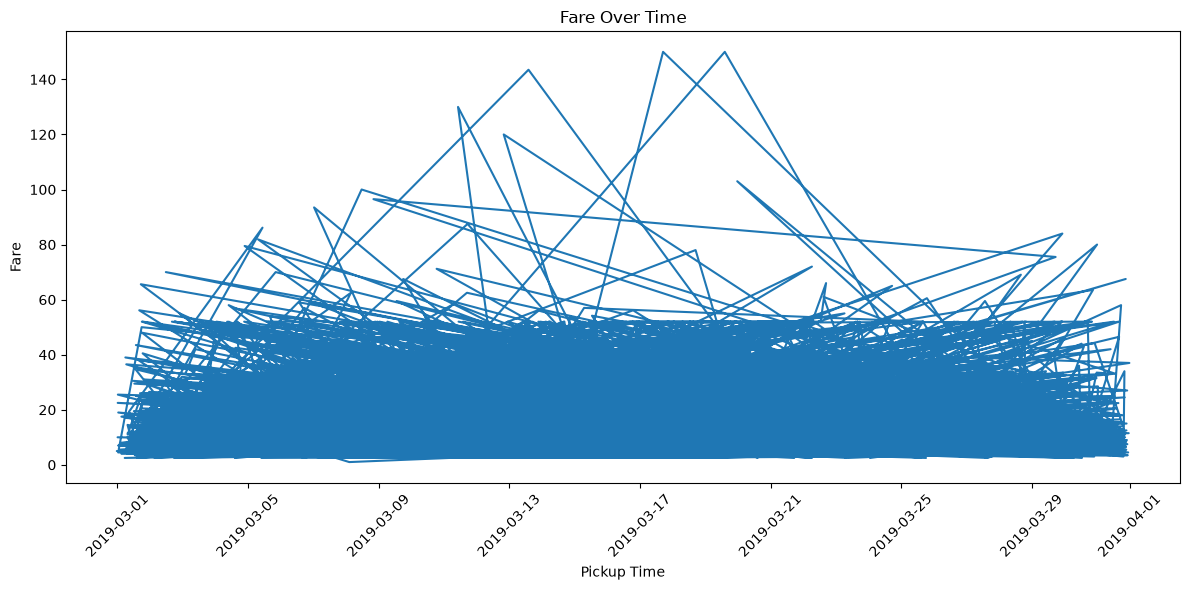

In [10]:
# ------------------------------------------
# 3.1 Line Chart
# ------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(df['pickup'], df['fare'])

plt.xlabel("Pickup Time")
plt.ylabel("Fare")
plt.title("Fare Over Time")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

     Month      fare
0  2019-02      5.00
1  2019-03  84209.87


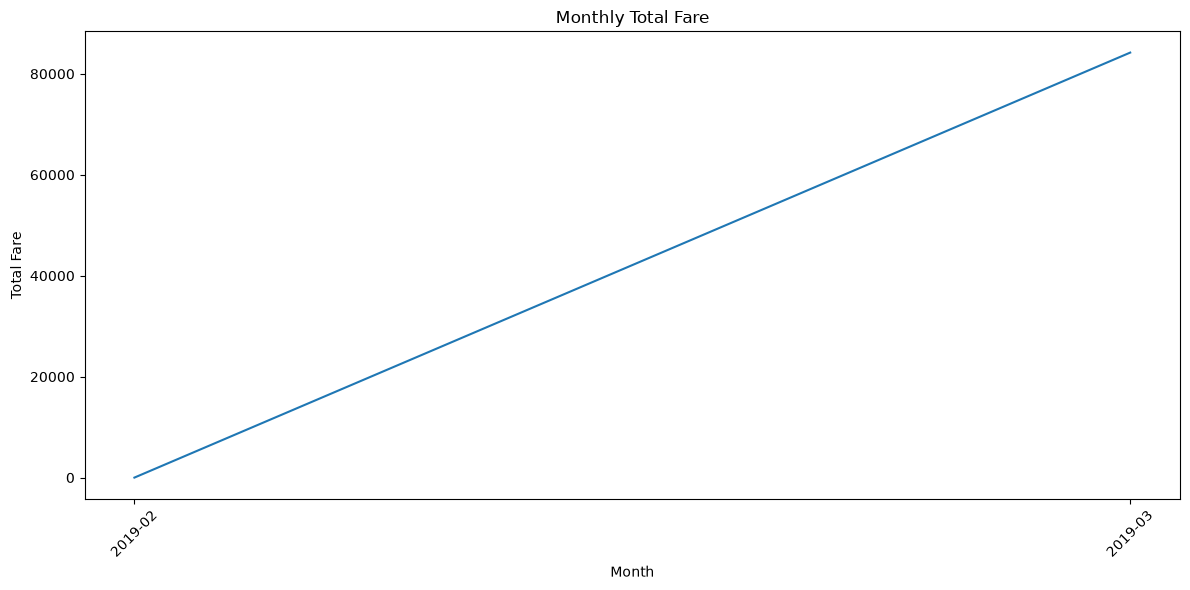

In [ ]:
# ------------------------------------------
# 3.1 Line Chart
# ------------------------------------------

# Grouping all trips by month

# Convert pickup column to datetime
df['pickup'] = pd.to_datetime(df['pickup'])

# Create month column
df['Month'] = df['pickup'].dt.to_period('M')

# Group data by month and calculate total fare
monthly_data = df.groupby('Month')['fare'].sum().reset_index()

# Display monthly data
print(monthly_data)

# Plot monthly total fare
plt.figure(figsize=(12, 6))

plt.plot(monthly_data['Month'].astype(str), monthly_data['fare'])

plt.xlabel("Month")
plt.ylabel("Total Fare")
plt.title("Monthly Total Fare")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

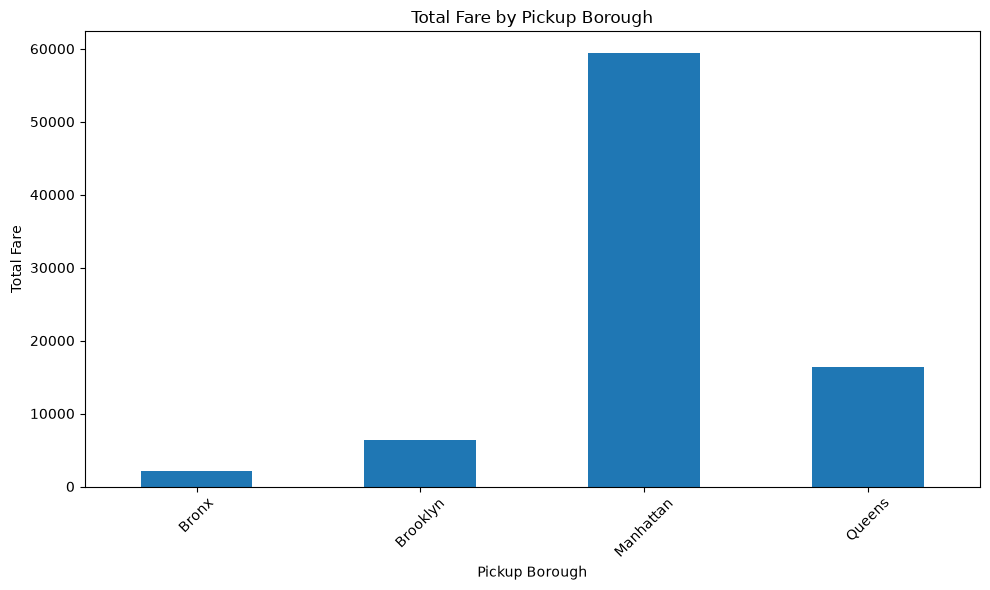

In [13]:
# ------------------------------------------
# 3.2 Bar Chart
# ------------------------------------------

borough_fare = df.groupby('pickup_borough')['fare'].sum()

borough_fare.plot(kind='bar', figsize=(10, 6))

plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")
plt.title("Total Fare by Pickup Borough")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


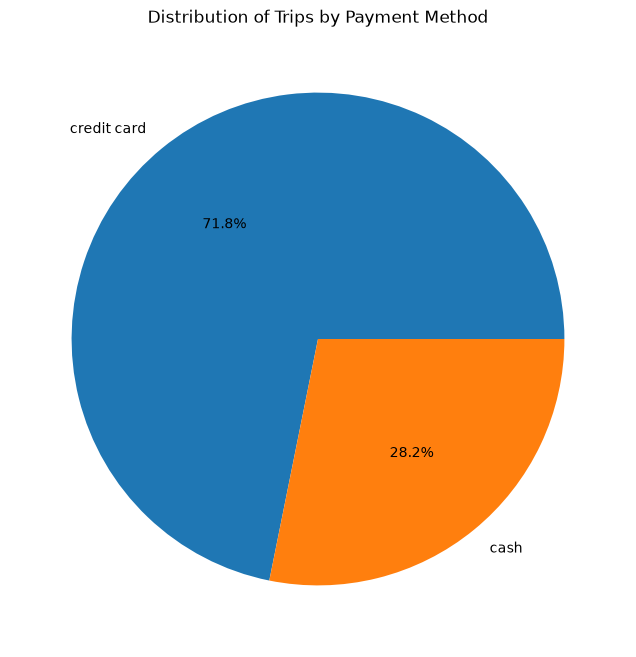

In [14]:
# ------------------------------------------
# 3.3 Pie Chart
# ------------------------------------------

payment_counts = df['payment'].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Distribution of Trips by Payment Method")

plt.show()


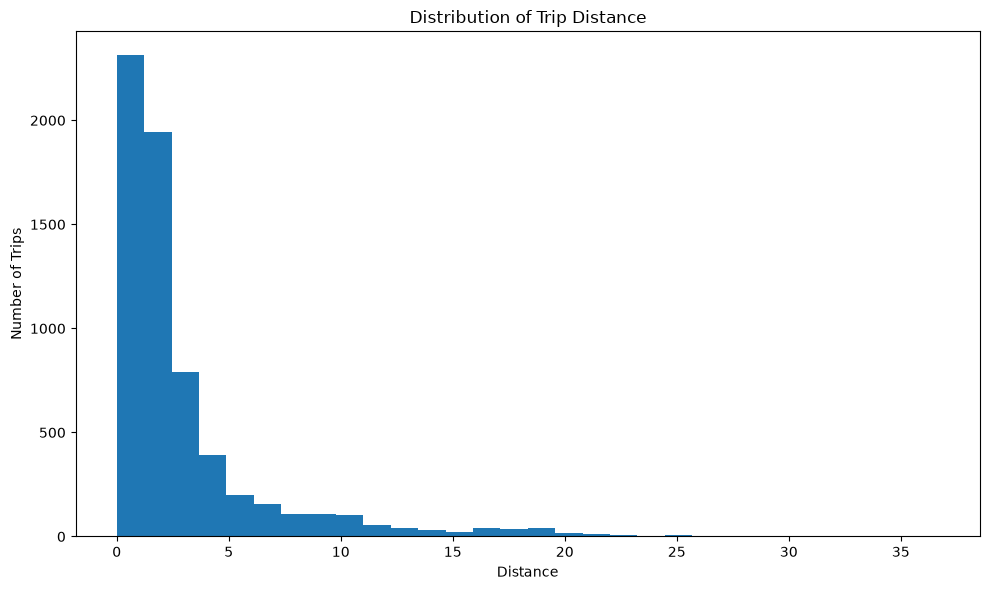

In [15]:
# ------------------------------------------
# 3.4 Histogram
# ------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(df['distance'], bins=30)

plt.xlabel("Distance")
plt.ylabel("Number of Trips")
plt.title("Distribution of Trip Distance")

plt.tight_layout()

plt.show()


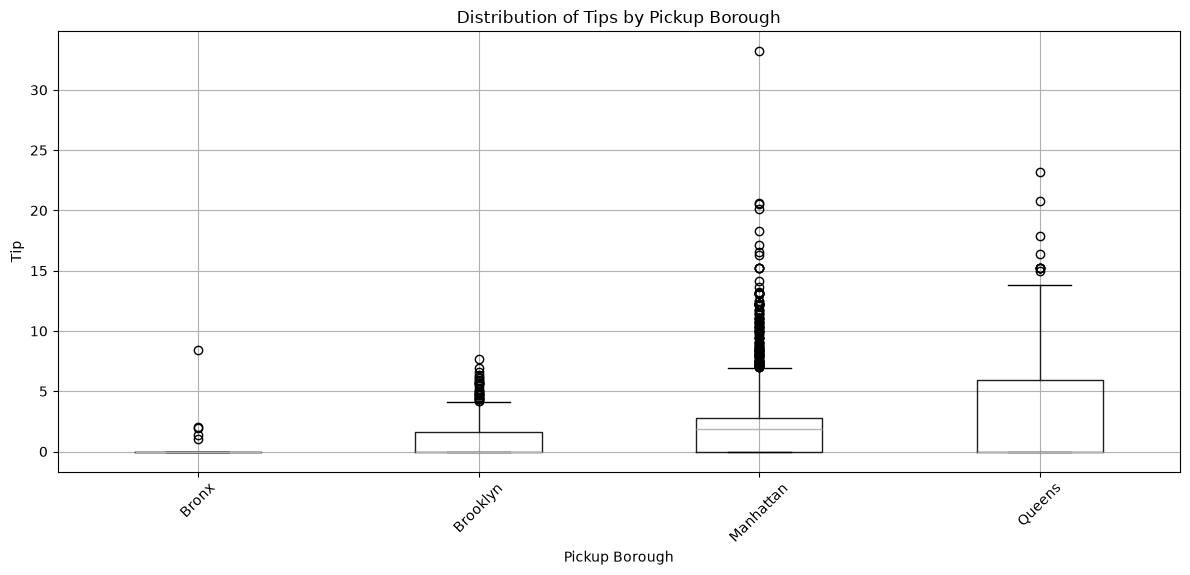

In [16]:
# ------------------------------------------
# 3.5 Box Plot
# ------------------------------------------

df.boxplot(
    column='tip',
    by='pickup_borough',
    figsize=(12, 6)
)

plt.xlabel("Pickup Borough")
plt.ylabel("Tip")
plt.title("Distribution of Tips by Pickup Borough")

plt.suptitle("")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


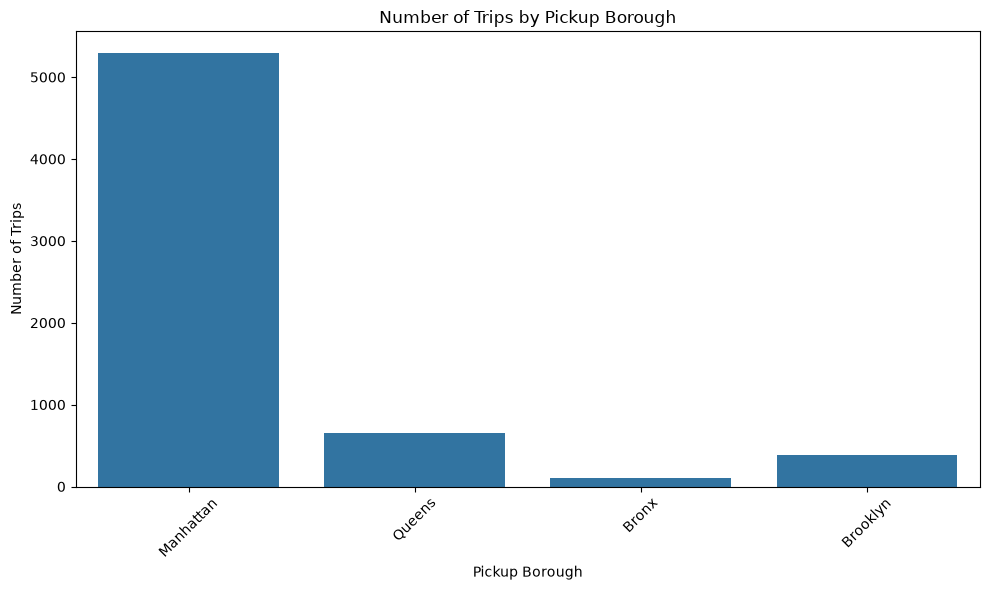

In [17]:
# ------------------------------------------
# 4.1 Seaborn Count Plot
# ------------------------------------------

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='pickup_borough'
)

plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")
plt.title("Number of Trips by Pickup Borough")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


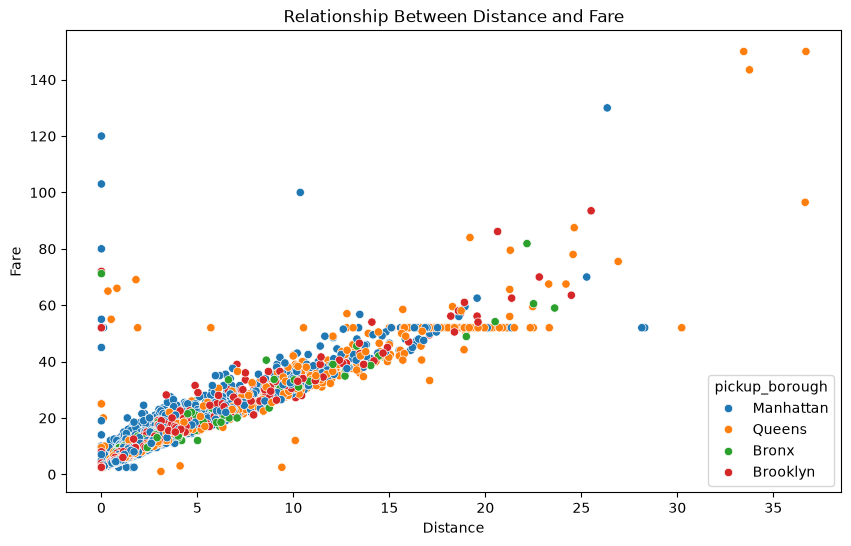

In [18]:
# ------------------------------------------
# 4.2 Seaborn Scatter Plot
# ------------------------------------------

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='distance',
    y='fare',
    hue='pickup_borough'
)

plt.xlabel("Distance")
plt.ylabel("Fare")
plt.title("Relationship Between Distance and Fare")

plt.show()


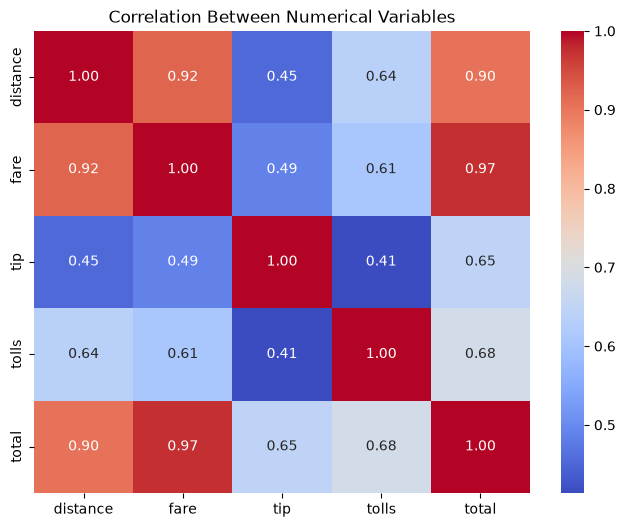

In [19]:
# ------------------------------------------
# 4.3 Heatmap
# ------------------------------------------

numeric_data = df[
    ['distance', 'fare', 'tip', 'tolls', 'total']
]

correlation = numeric_data.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Between Numerical Variables")

plt.show()


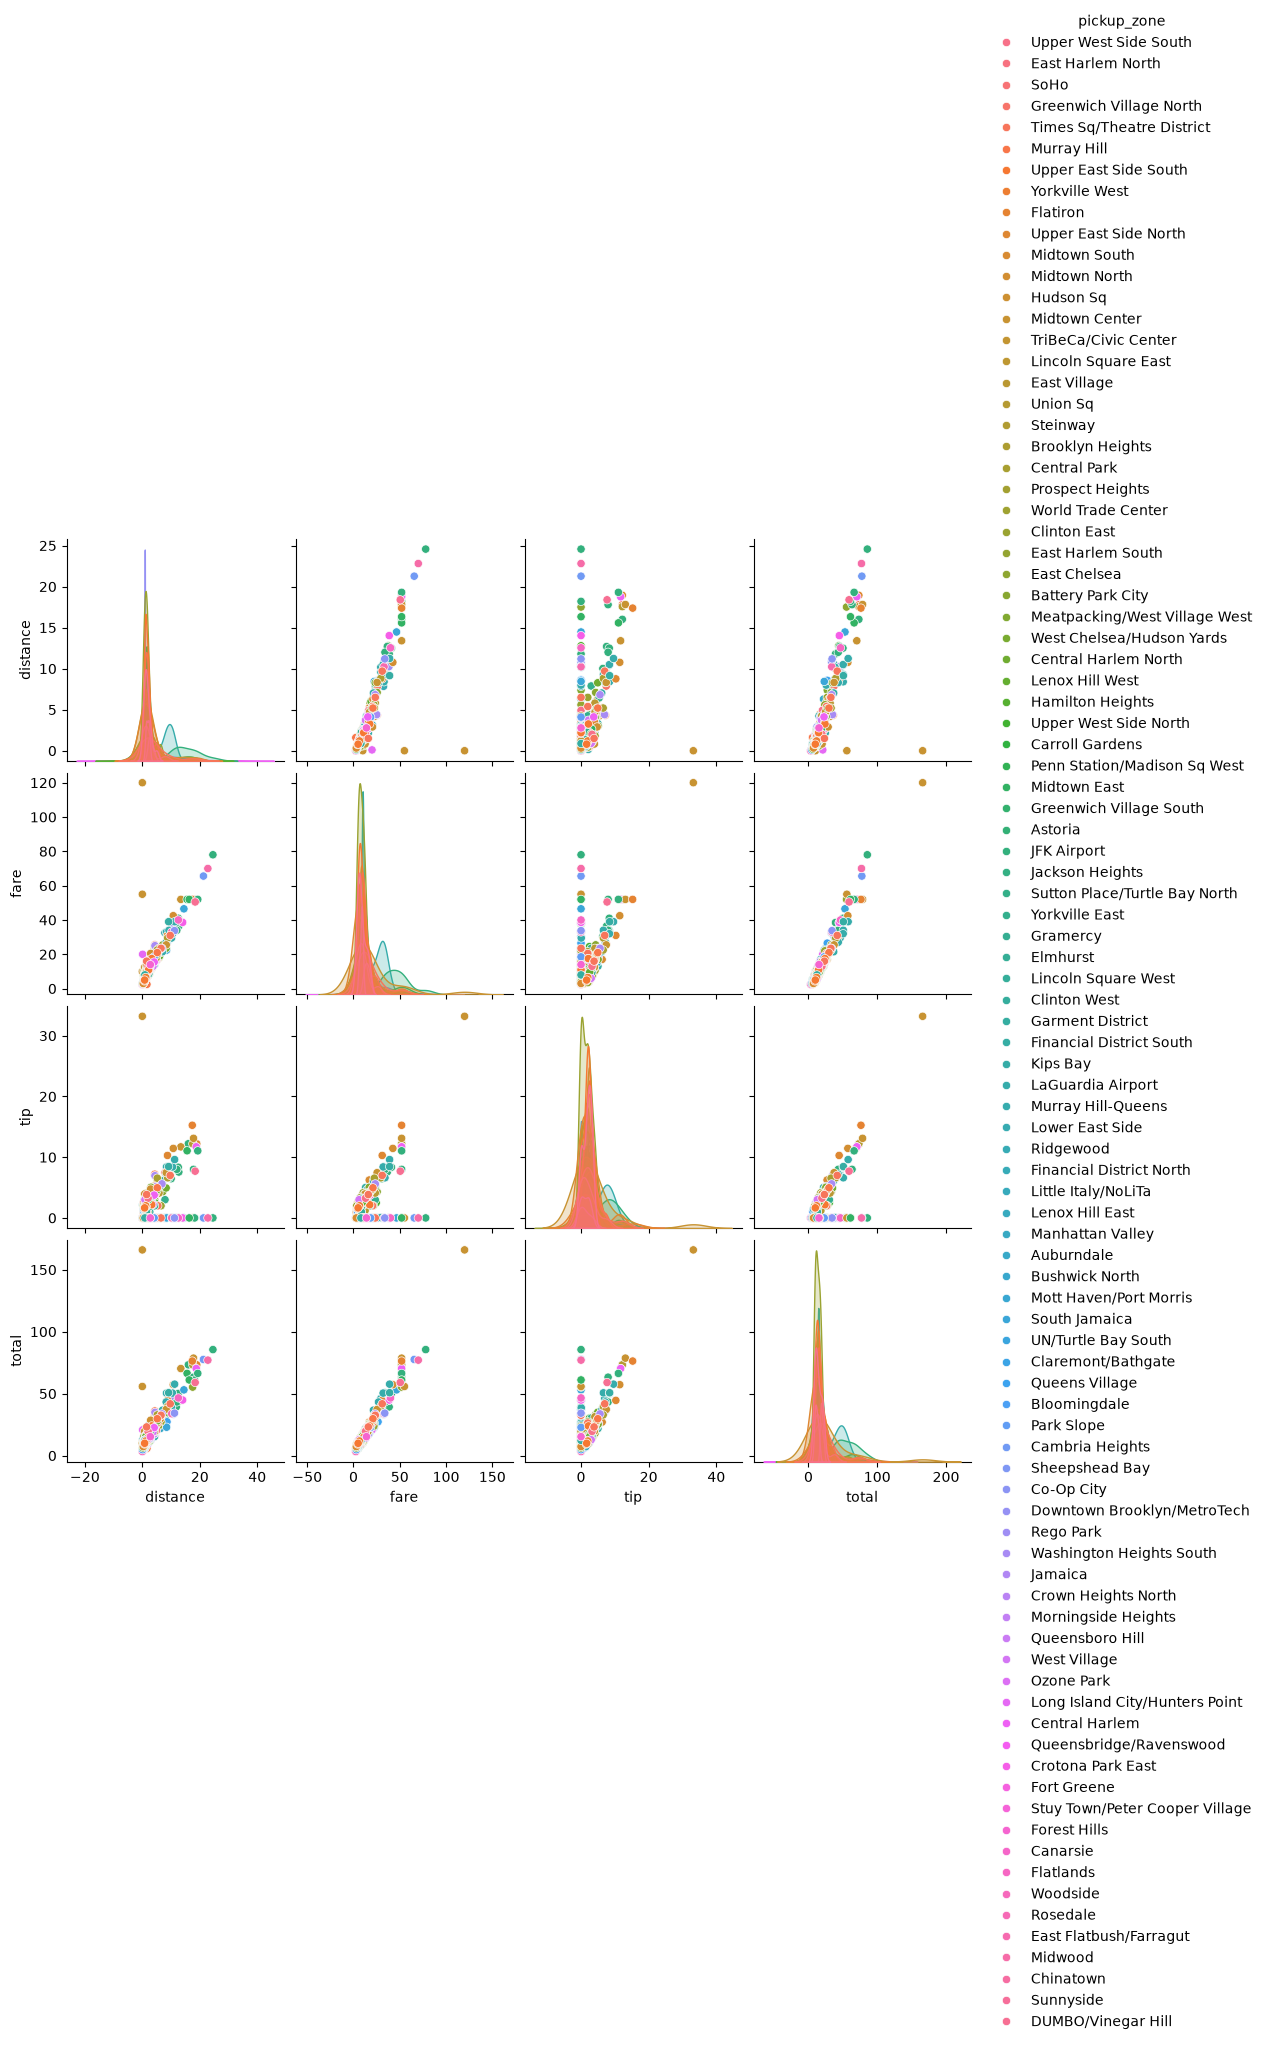

In [20]:
# ------------------------------------------
# 4.4 Pair Plot
# ------------------------------------------

sample_df = df.sample(500, random_state=42)

sns.pairplot(
    sample_df,
    vars=['distance', 'fare', 'tip', 'total'],
    hue='pickup_zone'
)

plt.show()

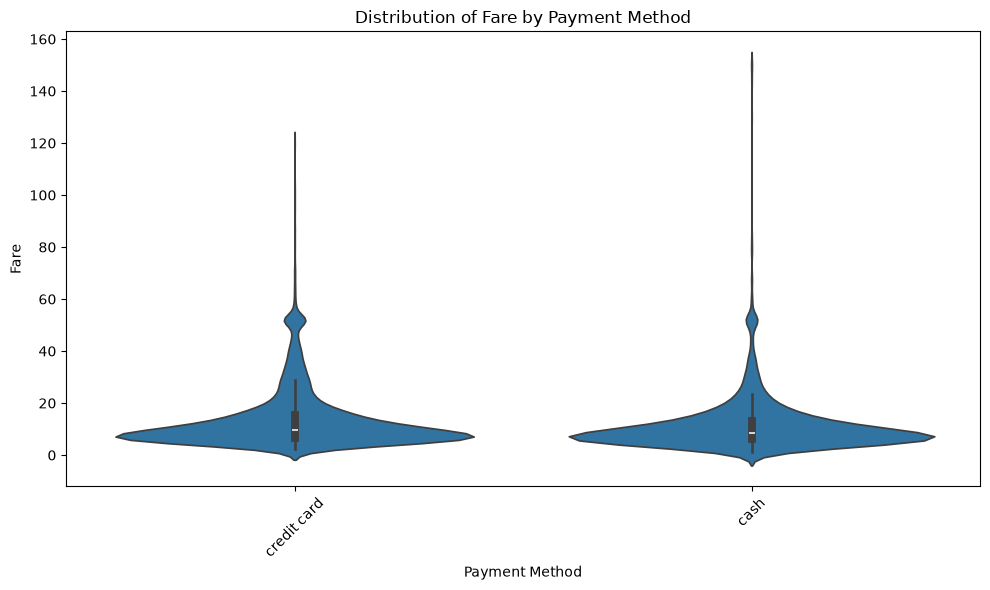

In [21]:
# ------------------------------------------
# 4.5 Violin Plot
# ------------------------------------------

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='payment',
    y='fare'
)

plt.xlabel("Payment Method")
plt.ylabel("Fare")
plt.title("Distribution of Fare by Payment Method")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()